In [1]:
### Global imports
import dill
from cse6040_devkit import plugins, utils
from cse6040_devkit.training_wheels import run_with_timeout, suppress_stdout
import tracemalloc
from time import time

utils.add_from_file('df_level_apply_checker', plugins)
utils.add_from_file('melt_blocker', plugins)
utils.add_from_file('pivot_table_blocker', plugins)


cse6040_devkit.plugins
cse6040_devkit.plugins
cse6040_devkit.plugins


In [2]:
# Some modules you'll need in this part
import pandas as pd
import numpy as np
from io import StringIO
from IPython.display import display
import re

# Part 0: Getting the data

Before beginning, you'll need to download several files containing the data for the exercises below.

**Ungraded**. Run the code cell below to download the data.

In [3]:
irises = pd.read_csv('resource/asnlib/publicdata/iris.csv')
table1 = pd.read_csv('resource/asnlib/publicdata/table1.csv')
table2 = pd.read_csv('resource/asnlib/publicdata/table2.csv')
table3 = pd.read_csv('resource/asnlib/publicdata/table3.csv')
table4a = pd.read_csv('resource/asnlib/publicdata/table4a.csv')
table4b = pd.read_csv('resource/asnlib/publicdata/table4b.csv')
who = pd.read_csv('resource/asnlib/publicdata/who.csv')
who2 = pd.read_csv('resource/asnlib/publicdata/who2_soln.csv')

print("\n(All data appear to be ready.)")


(All data appear to be ready.)


# Part 1: Tidy data 

The overall topic for this lab is what we'll refer to as representing data _relationally_. The topic of this part is a specific type of relational representation sometimes referred to as the _tidy_ (as opposed to _untidy_ or _messy_) form. The concept of tidy data was developed by [Hadley Wickham](http://hadley.nz/), a statistician and R programming maestro. Much of this lab is based on his tutorial materials (see below).

If you know [SQL](https://en.wikipedia.org/wiki/SQL), then you are already familiar with relational data representations. However, we might discuss it a little differently from the way you may have encountered the subject previously. The main reason is our overall goal in the class: to build data _analysis_ pipelines. If our end goal is analysis, then we often want to extract or prepare data in a way that makes analysis easier.

You may find it helpful to also refer to the original materials on which this lab is based:

* Wickham's R tutorial on making data tidy: http://r4ds.had.co.nz/tidy-data.html
* The slides from a talk by Wickham on the concept: http://vita.had.co.nz/papers/tidy-data-pres.pdf  
<!--- Broken Link * Wickham's more theoretical paper of "tidy" vs. "untidy" data: http://www.jstatsoft.org/v59/i10/paper -->

------------------------------------------------------------

## What is tidy data?

To build your intuition, consider the following data set collected from a survey or study.

**Representation 1.** [Two-way contigency table](https://en.wikipedia.org/wiki/Contingency_table).

|            | Pregnant | Not pregnant |
|-----------:|:--------:|:------------:|
| **Male**   |     0    |      5       |
| **Female** |     1    |      4       |

**Representation 2.** Observation list or "data frame."

| Gender  | Pregnant | Count |
|:-------:|:--------:|:-----:|
| Male    | Yes      | 0     |
| Male    | No       | 5     |
| Female  | Yes      | 1     |
| Female  | No       | 4     |

These are two entirely equivalent ways of representing the same data. However, each may be suited to a particular task.

For instance, Representation 1 is a typical input format for statistical routines that implement Pearson's $\chi^2$-test, which can check for independence between factors. (Are gender and pregnancy status independent?) By contrast, Representation 2 might be better suited to regression. (Can you predict relative counts from gender and pregnancy status?)

While [Representation 1 has its uses](http://simplystatistics.org/2016/02/17/non-tidy-data/), Wickham argues that Representation 2 is often the cleaner and more general way to supply data to a wide variety of statistical analysis and visualization tasks. He refers to Representation 2 as _tidy_ and Representation 1 as _untidy_ or _messy_.

> The term "messy" is, as Wickham states, not intended to be perjorative since "messy" representations may be exactly the right ones for particular analysis tasks, as noted above.

**Definition: Tidy datasets.** More specifically, Wickham defines a tidy data set as one that can be organized into a 2-D table such that

1. each column represents a _variable_;
2. each row represents an _observation_;
3. each entry of the table represents a single _value_, which may come from either categorical (discrete) or continuous spaces.

Here is a visual schematic of this definition, taken from [another source](http://r4ds.had.co.nz/images/tidy-1.png):

![Wickham's illustration of the definition of tidy](http://r4ds.had.co.nz/images/tidy-1.png)

This definition appeals to a statistician's intuitive idea of data he or she wishes to analyze. It is also consistent with tasks that seek to establish a functional relationship between some response (output) variable from one or more independent variables.

> A computer scientist with a machine learning outlook might refer to columns as _features_ and rows as _data points_, especially when all values are numerical (ordinal or continuous).

**Definition: Tibbles.** Here's one more bit of terminology: if a table is tidy, we will call it a _tidy table_, or _tibble_, for short.

## Part 2: Tidy Basics and Pandas

In Python, the [Pandas](http://pandas.pydata.org/) module is a convenient way to store tibbles. If you know [R](http://r-project.org), you will see that the design and API of Pandas's data frames derives from [R's data frames](https://stat.ethz.ch/R-manual/R-devel/library/base/html/data.frame.html).

In this part of this notebook, let's look at how Pandas works and can help us store Tidy data.

You may find this introduction to the Pandas module's data structures useful for reference:

* https://pandas.pydata.org/pandas-docs/stable/dsintro.html

Consider the famous [Iris data set](https://en.wikipedia.org/wiki/Iris_flower_data_set). It consists of 50 samples from each of three species of Iris (_Iris setosa_, _Iris virginica_, and _Iris versicolor_). Four features were measured from each sample: the lengths and the widths of the [sepals](https://en.wikipedia.org/wiki/Sepal) and [petals](https://en.wikipedia.org/wiki/Petal).

The following code uses Pandas to read and represent this data in a Pandas data frame object, stored in a variable named `irises`.

In [4]:
print("=== Iris data set: {} rows x {} columns. ===".format(irises.shape[0], irises.shape[1]))
display (irises.head())

=== Iris data set: 150 rows x 5 columns. ===


,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In a Pandas data frame, every column has a name (stored as a string) and all values within the column must have the same primitive type. This fact makes columns different from, for instance, lists.

In addition, every row has a special column, called the data frame's _index_. (Try printing `irises.index`.) Any particular index value serves as a name for its row; these index values are usually integers but can be more complex types, like tuples.

In [5]:
print(irises.index)

RangeIndex(start=0, stop=150, step=1)


Separate from the index values (row names), you can also refer to rows by their integer offset from the top, where the first row has an offset of 0 and the last row has an offset of `n-1` if the data frame has `n` rows. You'll see that in action in Exercise 1, below.

**Ungraded**. Run the following commands to understand what each one does. If it's not obvious, try reading the [Pandas documentation](http://pandas.pydata.org/) or going online to get more information.

```python
irises.describe()
irises['sepal length'].head()
irises[["sepal length", "petal width"]].head()
irises.iloc[5:10]
irises[irises["sepal length"] > 5.0]
irises["sepal length"].max()
irises['species'].unique()
irises.sort_values(by="sepal length", ascending=False).head(1)
irises.sort_values(by="sepal length", ascending=False).iloc[5:10]
irises.sort_values(by="sepal length", ascending=False).loc[5:10]
irises['x'] = 3.14
irises.rename(columns={'species': 'type'})
del irises['x']
```

In [6]:
#irises.describe()
#irises['sepal length'].head()
#irises[["sepal length", "petal width"]].head()
#irises.iloc[5:10]
#irises[irises["sepal length"] > 5.0]
#irises["sepal length"].max()
#irises['species'].unique()
#sort_values(by="sepal length", ascending=False).head(1)
#irises.sort_values(by="sepal length", ascending=False).iloc[5:10]
#irises.sort_values(by="sepal length", ascending=False).loc[5:10]
#irises['x'] = 3.14
#irises.rename(columns={'species': 'type'})
del irises['x']

KeyError: 'x'

## Merging data frames: join operations

Another useful operation on data frames is [merging](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.merge.html).

For instance, consider the following two tables, `A` and `B`:

| country     | year | cases  |
|:------------|-----:|-------:|
| Afghanistan | 1999 |    745 |
| Brazil      | 1999 |  37737 |
| China       | 1999 | 212258 |
| Afghanistan | 2000 |   2666 |
| Brazil      | 2000 |  80488 |
| China       | 2000 | 213766 |

| country     | year | population |
|:------------|-----:|-----------:|
| Afghanistan | 1999 |   19987071 |
| Brazil      | 1999 |  172006362 |
| China       | 1999 | 1272915272 |
| Afghanistan | 2000 |   20595360 |
| Brazil      | 2000 |  174504898 |
| China       | 2000 | 1280428583 |

Suppose we wish to combine these into a single table, `C`:

| country     | year | cases  | population |
|:------------|-----:|-------:|-----------:|
| Afghanistan | 1999 |    745 |   19987071 |
| Brazil      | 1999 |  37737 |  172006362 |
| China       | 1999 | 212258 | 1272915272 |
| Afghanistan | 2000 |   2666 |   20595360 |
| Brazil      | 2000 |  80488 |  174504898 |
| China       | 2000 | 213766 | 1280428583 |

In Pandas, you can perform this merge using the [`.merge()` function](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.merge.html):

```python
C = A.merge (B, on=['country', 'year'])
```

In this call, the `on=` parameter specifies the list of column names to use to align or "match" the two tables, `A` and `B`. By default, `merge()` will only include rows from `A` and `B` where all keys match between the two tables.

The following code cell demonstrates this functionality.

In [ ]:
A_csv = """country,year,cases
Afghanistan,1999,745
Brazil,1999,37737
China,1999,212258
Afghanistan,2000,2666
Brazil,2000,80488
China,2000,213766"""

with StringIO(A_csv) as fp:
    A = pd.read_csv(fp)
print("=== A ===")
display(A)

In [ ]:
B_csv = """country,year,population
Afghanistan,1999,19987071
Brazil,1999,172006362
China,1999,1272915272
Afghanistan,2000,20595360
Brazil,2000,174504898
China,2000,1280428583"""

with StringIO(B_csv) as fp:
    B = pd.read_csv(fp)
print("\n=== B ===")
display(B)

In [ ]:
C = A.merge(B, on=['country', 'year'])
print("\n=== C = merge(A, B) ===")
display(C)

**Joins.** This default behavior of keeping only rows that match both input frames is an example of what relational database systems call an _inner-join_ operation. But there are several other types of joins.

- _Inner-join (`A`, `B`)_ (default): Keep only rows of `A` and `B` where the on-keys match in both.
- _Outer-join (`A`, `B`)_: Keep all rows of both frames, but merge rows when the on-keys match. For non-matches, fill in missing values with not-a-number (`NaN`) values.
- _Left-join (`A`, `B`)_: Keep all rows of `A`. Only merge rows of `B` whose on-keys match `A`.
- _Right-join (`A`, `B`)_: Keep all rows of `B`. Only merge rows of `A` whose on-keys match `B`.

You can use `merge`'s `how=...` parameter, which takes the (string) values, `'inner`', `'outer'`, `'left'`, and `'right'`. Here are some examples of these types of joins.

In [ ]:
with StringIO("""x,y,z
bug,1,d
rug,2,d
lug,3,d
mug,4,d""") as fp:
    D = pd.read_csv(fp)
print("=== D ===")
display(D)

with StringIO("""x,y,w
hug,-1,e
smug,-2,e
rug,-3,e
tug,-4,e
bug,1,e""") as fp:
    E = pd.read_csv(fp)
print("\n=== E ===")
display(E)

print("\n=== Outer-join (D, E) ===")
display(D.merge(E, on=['x', 'y'], how='outer'))

print("\n=== Left-join (D, E) ===")
display(D.merge(E, on=['x', 'y'], how='left'))

print("\n=== Right-join (D, E) ===")
display(D.merge(E, on=['x', 'y'], how='right'))


print("\n=== Inner-join (D, E) ===")
display(D.merge(E, on=['x', 'y']))

## Apply functions to data frames

Another useful primitive is `apply()`, which can apply a function to a data frame or to a series (column of the data frame).

For instance, suppose we wish to convert the year column in `C` into an abbrievated two-digit form. The following code will do it:

In [ ]:
display(C)
G = C.copy() # If you do not use copy function the original data frame is modified
G['year'] = G['year'].apply(lambda x: "'{:02d}".format(x % 100))
display(G)

### Exercise 0: (2 points)
**calc_prevalence**  

**Your task:** define `calc_prevalence` as follows:

Suppose you wish to compute the prevalence, which is the ratio of cases to the population.

The simplest way to do it is as follows:

```python
G['prevalence'] = G['cases'] / G['population']
```
However, for this exercise, try to figure out how to use `apply()` to do it instead. To figure that out, you'll need to consult the documentation for [`apply()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.apply.html) or go online to find some hints.

**Inputs**: `G`, a dataframe with various columns and guaranteed to have the following 2 columns:
- `cases`
- `population`

**Return**: `H`, a *new* dataframe that is a copy of `G` with the addition of a new column named `'prevalence'` holding the correctly computed prevalence values.

**Requirements/steps**: 
- Do not modify the input dataframe `G`    
- Although there is the easy solution above, the purpose of this exercise is to force you to learn more about how `apply()` works, so that you can "apply" it in more settings in the future.


In [ ]:
### Solution - Exercise 0  
def calc_prevalence(G):
    assert 'cases' in G.columns and 'population' in G.columns
    H = G.copy()
    H['prevalence'] = H.apply(lambda row: row['cases'] / row['population'], axis = 1)
    return H

### Demo function call
calc_prevalence_df = calc_prevalence(G)
calc_prevalence_df

 **Example**. A correct implementation should produce, for the demo, the following output:

|     | country     | year | cases  | population  | prevalence  |
|-----|-------------|------|--------|-------------|-------------|
|0    | Afghanistan | '99  | 745    | 19987071    | 0.000037    |
|1    | Brazil      | '99  | 37737  | 172006362   | 0.000219    |
|2    | China       | '99  | 212258 | 1272915272  | 0.000167    |
|3    | Afghanistan | '00  | 2666   | 20595360    | 0.000129    |
|4    | Brazil      | '00  | 80488  | 174504898   | 0.000461    |
|5    | China       | '00  | 213766 | 1280428583  | 0.000167    |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for calc_prevalence (exercise 0). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 0  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=plugins.df_level_apply_checker(calc_prevalence),
              ex_name='calc_prevalence',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to calc_prevalence did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

## Part 3 : Tibbles and Bits 

Now let's start creating and manipulating tibbles.

### Exercise 1: (3 points)
**canonicalize_tibble**  

**Your task:** define `canonicalize_tibble` as follows:

Given a tibble `X`, return a new copy `Y` of `X` in _canonical order_. We say `Y` is in canonical order if it has the following properties.

1. The variables appear in sorted order by name, ascending from left to right.
2. The rows appear in lexicographically sorted order by variable, ascending from top to bottom.
3. The row labels (`Y.index`) go from 0 to `n-1`, where `n` is the number of observations.

For instance, here is a **non-canonical tibble** ...

|   |  c  | a | b |
|:-:|:---:|:-:|:-:|
| 2 | hat | x | 1 |
| 0 | rat | y | 4 |
| 3 | cat | x | 2 |
| 1 | bat | x | 2 |


... and here is its **canonical counterpart.**

|   | a | b |  c  |
|:-:|:-:|:-:|:---:|
| 0 | x | 1 | hat |
| 1 | x | 2 | bat |
| 2 | x | 2 | cat |
| 3 | y | 4 | rat |

A partial solution appears below, which ensures that Property 1 above holds. Complete the solution to ensure Properties 2 and 3 hold. Feel free to consult the [Pandas API](http://pandas.pydata.org/pandas-docs/stable/api.html).

> **Hint**. For Property 3, you may find `reset_index()` handy: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.reset_index.html


In [ ]:
### Solution - Exercise 1  
def canonicalize_tibble(X):
    # Enforce Property 1:
    var_names = sorted(X.columns)
    Y = X[var_names].copy()
    #property 2, sort lexicographically
    Y.sort_values(by=var_names, inplace=True)
    #PROPERTY 3, row labels (Y.index) go from 0 to n-1
    Y.set_index([list(range(0, len(Y)))], inplace=True)

   
    return Y

### Demo function call
demo_X_ex1 = pd.DataFrame({
    'c': ['hat', 'rat', 'cat', 'bat'],
    'a': ['x', 'y', 'x', 'x'],
    'b': [1, 4, 2, 2]
}, index=[2, 0, 3, 1])

demo_output_ex1 = canonicalize_tibble(demo_X_ex1)
demo_output_ex1

**Example**. A correct implementation should produce, for the demo, the following output:
    
|   | a | b |  c  |
|:-:|:-:|:-:|:---:|
| 0 | x | 1 | hat |
| 1 | x | 2 | bat |
| 2 | x | 2 | cat |
| 3 | y | 4 | rat |

 


 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for canonicalize_tibble (exercise 1). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 1  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=canonicalize_tibble,
              ex_name='canonicalize_tibble',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to canonicalize_tibble did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

## Check dataframes for equivalence programatically

Often times, a visual inspection will not spot the underlying differences between dataframes. Therefore, we need a more reliable solution to catch every difference every time.

This is where [`assert_frame_equal()`](https://pandas.pydata.org/docs/reference/api/pandas.testing.assert_frame_equal.html) shines.

Let's walk through a few examples.

In [ ]:
from pandas.testing import assert_frame_equal

In [ ]:
# Example 1: Equal dataframes

X_df = pd.DataFrame({
    'a': ['x', 'y', 'z', 'w'],
    'b': [1, 2, 3, 4],
    'c': ['hat', 'cat', 'bat', 'rat']})
display(X_df)

try:
    assert_frame_equal(X_df, X_df)
    print('Tibbles are equivalent!')
except AssertionError as error_message:
    print(error_message)

We are comparing the same dataframe to itself, so we know they are equal. `assert_frame_equal()` agrees with us.

In [ ]:
# Example 2: Dataframes with different shapes

# let's remove the first row of X_df and call this new object `Y_df`
Y_df = X_df.iloc[1:]
display(Y_df)

try:
    assert_frame_equal(X_df, Y_df)
    print('Tibbles are equivalent!')
except AssertionError as error_message:
    print(error_message)

The error message tell us exactly what the difference is! There's a shape mismatch where the left dataframe, `X_df`, is (4, 3), and the right dataframe, `Y_df`, is (3, 3).

In [ ]:
# Example 3: Identical data but columns have different names

# let's create a new df with a single column renamed
Z_df = X_df.rename(columns={'c': 'd'})
display(Z_df)

try:
    assert_frame_equal(X_df, Z_df)
    print('Tibbles are equivalent!')
except AssertionError as error_message:
    print(error_message)

In [ ]:
# Example 4: Visually identical but different underlying data types

int8_df = pd.DataFrame({
    'a': [1, 2, 3, 4],
    'b': [1, 2, 3, 4],
    'c': [1, 2, 3, 4]}, dtype=np.int8)
display(int8_df)

int32_df = pd.DataFrame({
    'a': [1, 2, 3, 4],
    'b': [1, 2, 3, 4],
    'c': [1, 2, 3, 4]}, dtype=np.int32)
display(int32_df)

try:
    assert_frame_equal(int8_df, int32_df)
    print('Tibbles are equivalent!')
except AssertionError as error_message:
    print(error_message)

### Exercise 2: (1 points)
**tibbles_are_equivalent**  

**Your task:** define `tibbles_are_equivalent` as follows:

Determine if two tibbles, `A` and `B`, are equivalent. "Equivalent" means that `A` and `B` have identical variables and observations, up to permutations. If `A` and `B` are equivalent, then the function should return `Tibbles are equivalent!`. Otherwise, it should return an error message.

The last condition, "up to permutations," means that the variables and observations might not appear in the table in the same order. For example, the following two tibbles are equivalent:


| a | b |  c  |
|:-:|:-:|:---:|
| x | 1 | hat |
| y | 2 | cat |
| z | 3 | bat |
| w | 4 | rat |

| b |  c  | a |
|:-:|:---:|:-:|
| 2 | cat | y |
| 3 | bat | z |
| 1 | hat | x |
| 4 | rat | w |

By contrast, the following table would not be equivalent to either of the above tibbles.

| a | b |  c  |
|:-:|:-:|:---:|
| 2 | y | cat |
| 3 | z | bat |
| 1 | x | hat |
| 4 | w | rat |

While there are many different methods to solve this problem, you must use [`assert_frame_equal()`](https://pandas.pydata.org/docs/reference/api/pandas.testing.assert_frame_equal.html) to solve it. Please take a look at the documentation and function parameters. `assert_frame_equal()` raises an `AssertionError` in the case of unequal pandas objects and returns nothing in the case of equal objects. The function below is set up to handle the output after `assert_frame_equal()` is called. The starter code will return a string stating equality or the original error message when not equal. 

> **Note 0**: Unlike Pandas data frames, tibbles conceptually do not have row labels. So you should ignore row labels.
>
> **Note 1.** The purpose of this exercise is to force you to learn more about how `assert_frame_equal()` works, so it is required to use in this exercise when checking for equivalence.



In [ ]:
### Solution - Exercise 2  
def tibbles_are_equivalent(A, B):
    from pandas.testing import assert_frame_equal
    try:
        #sort order of columns first, align columns
        A = A.reindex(sorted(A.columns), axis=1)
        B = B.reindex(sorted(B.columns), axis=1)
        
        #sort values and reset index next
        
        A_sorted = A.sort_values(by=list(A.columns)).reset_index(drop=True)
        B_sorted = B.sort_values(by=list(B.columns)).reset_index(drop=True)
        
        
        assert_frame_equal(A_sorted, B_sorted)
    
        return 'Tibbles are equivalent!'
    except AssertionError as error_message:
        return str(error_message)

### Demo function call
demo_tibble_A_ex2 = pd.DataFrame({
    'a': ['x', 'y', 'z', 'w'],
    'b': [1, 2, 3, 4],
    'c': ['hat', 'cat', 'bat', 'rat']})
demo_tibble_B_ex2 = pd.DataFrame({
    'b': [2, 3, 1, 4],
    'c': ['cat', 'bat', 'hat', 'rat'],
    'a': ['y', 'z', 'x', 'w']})
demo_tibble_C_ex2 = pd.DataFrame({
    'a': [2, 3, 1, 4],
    'b': ['y', 'z', 'x', 'w'],
    'c': ['cat', 'bat', 'hat', 'rat']})

demo_output_ex2 = tibbles_are_equivalent(demo_tibble_A_ex2, demo_tibble_B_ex2)
demo_output_ex2

 **Example**. A correct implementation should produce, for the demo, the following output:
```python
'Tibbles are equivalent!'
```



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for tibbles_are_equivalent (exercise 2). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 2  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=tibbles_are_equivalent,
              ex_name='tibbles_are_equivalent',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to tibbles_are_equivalent did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

# Basic tidying transformations: Melting and casting

Given a data set and a target set of variables, there are at least two common issues that require tidying.
## Melting
First, values often appear as columns. Table 4a is an example. To tidy up, you want to turn columns into rows:

![Gather example](http://r4ds.had.co.nz/images/tidy-9.png)

Because this operation takes columns into rows, making a "fat" table more tall and skinny, it is sometimes called _melting_.




To melt the table, you need to do the following.

1. Extract the _column values_ into a new variable. In this case, columns `"1999"` and `"2000"` of `table4` need to become the values of the variable, `"year"`.
2. Convert the values associated with the column values into a new variable as well. In this case, the values formerly in columns `"1999"` and `"2000"` become the values of the `"cases"` variable.

In the context of a melt, let's also refer to `"year"` as the new _key_ variable and `"cases"` as the new _value_ variable.

### Exercise 3: (4 points)
**melt**  

**Your task:** define `melt` as follows:


```python
    def melt(df, col_vals, key, value):
        ...
```

It should take the following arguments:
- `df`: the input data frame, e.g., `table4` in the example above;
- `col_vals`: a list of the column names that will serve as values;  column `1999` & `2000` in example table
- `key`: name of the new variable, e.g., `year` in the example above;
- `value`: name of the column to hold the values. `cases` in the example above

> **Note 0**: You may need to refer to the Pandas documentation to figure out how to create and manipulate tables. The bits related to [indexing](http://pandas.pydata.org/pandas-docs/stable/indexing.html) and [merging](http://pandas.pydata.org/pandas-docs/stable/merging.html) may be especially helpful.
>
> **Note 1**: There is a trivial solution to this exercise using `pandas.melt`. The purpose of this exercise it to become more familiar with manipulating dataframes, so the in-built `pd.melt` function will be blocked and the test cell will not pass solutions using it.



In [ ]:
### Solution - Exercise 3  
def melt(df, col_vals, key, value):
    assert type(df) is pd.DataFrame
    
    #return column names not in col_vals
    keep_cols = df.columns.difference(col_vals)
    melted_sections = []
    for c in col_vals:
        melted_copy = df[keep_cols].copy()
        melted_copy[key] = c #year : 1999
        melted_copy[value] = df[c]  #orig df cases column vals
        melted_sections.append(melted_copy)
    
    melted = pd.concat(melted_sections)  
        
    return melted.reset_index(drop=True)
        
  # Demo function call

demo_df_ex3 = pd.DataFrame({
    'country': ['Afghanistan', 'Brazil', 'China'],
    1999: [745, 37737, 212258],
    2000: [2666, 80488, 213766]
})
demo_col_vals_ex3 = [1999, 2000]
demo_key_ex3 = 'year'
demo_value_ex3 = 'cases'

demo_output_ex3 = melt(demo_df_ex3, demo_col_vals_ex3, demo_key_ex3, demo_value_ex3)
demo_output_ex3.reset_index(drop=True)

 **Example**. A correct implementation should produce, for the demo, the following output:

|    | country     | year | cases  |
|----|-------------|------|--------|
| 0  | Afghanistan | 1999 |    745 |
| 1  | Brazil      | 1999 |  37737 |
| 2  | China       | 1999 | 212258 |
| 3  | Afghanistan | 2000 |   2666 |
| 4  | Brazil      | 2000 |  80488 |
| 5  | China       | 2000 | 213766 |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for melt (exercise 3). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 3  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=plugins.melt_blocker(melt),
              ex_name='melt',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to melt did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

## Casting
The second most common issue is that an observation might be split across multiple rows. Table 2 is an example. To tidy up, you want to merge rows:

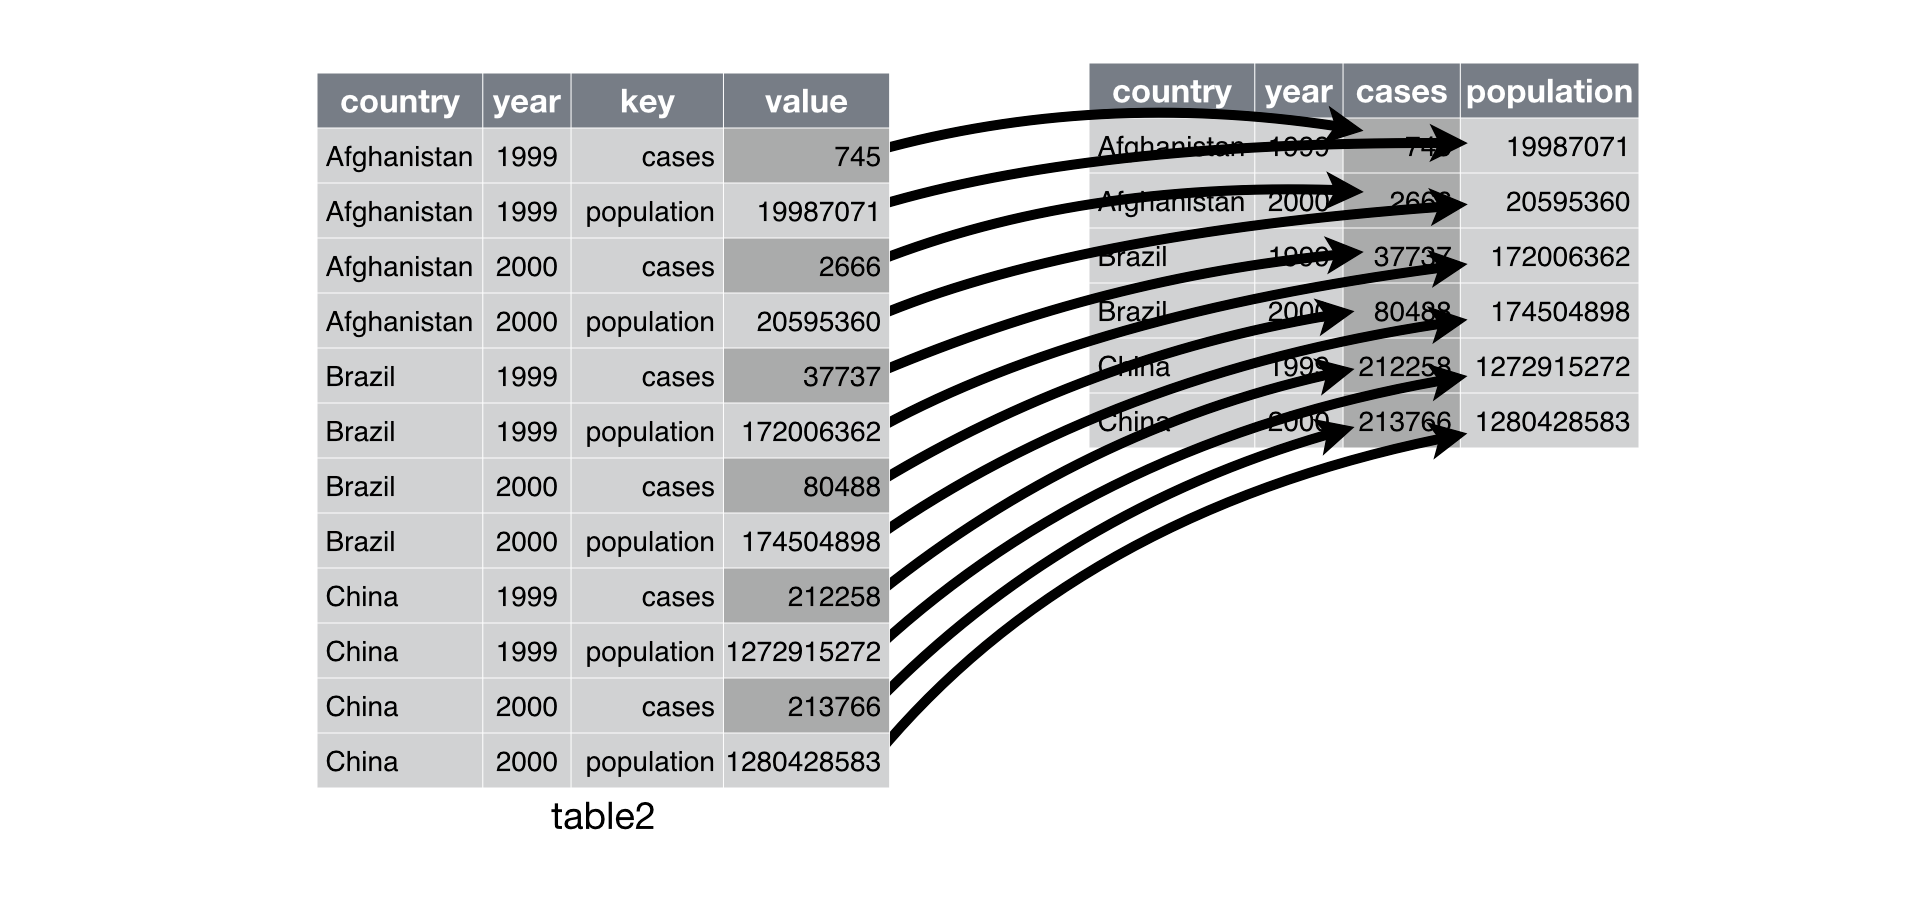

Because this operation is the moral opposite of melting, and "rebuilds" observations from parts, it is sometimes called _casting_.

<!--- link to original paper is broken [his original paper on tidying data](http://www.jstatsoft.org/v59/i10/paper) -->
> Melting and casting are Wickham's terms from his original paper on tidying data. In his more recent writing, [on which this tutorial is based](http://r4ds.had.co.nz/tidy-data.html), he refers to the same operation as _gathering_. Again, this term comes from Wickham's original paper, whereas his more recent summaries use the term _spreading_.

The signature of a cast is similar to that of melt. However, you only need to know the `key`, which is column of the input table containing new variable names, and the `value`, which is the column containing corresponding values.

### Exercise 4: (4 points)
**cast**  

**Your task:** define `cast` as follows:

Implement a function to cast a data frame into a tibble, given a key column containing new variable names and a value column containing the corresponding cells.

We've given you a partial solution that

- verifies that the given `key` and `value` columns are actual columns of the input data frame;
- computes the list of columns, `fixed_vars`, that should remain unchanged; and
- initializes and empty tibble.

Observe that we are asking your `cast()` to accept an optional parameter, `join_how`, that may take the values `'outer'` or `'inner'` (with `'outer'` as the default). Why do you need such a parameter?

> **Note 0**: There is a trivial solution to this exercise using `pandas.pivot_table` and `DataFrame.pivot`. The purpose of this exercise it to become more familiar with manipulating dataframes, so the two aforementioned in-built functions will be blocked and the test cell will not pass solutions using it.



In [ ]:
### Solution - Exercise 4  
def cast(df, key, value, join_how='outer'):
    """Casts the input data frame into a tibble,
    given the key column and value column.
    """
    assert type(df) is pd.DataFrame
    assert key in df.columns and value in df.columns
    assert join_how in ['outer', 'inner']
    
    fixed_vars = df.columns.difference([key, value])
    tibble = pd.DataFrame(columns=fixed_vars) # empty frame
    
    #get unique keys
    new_vars = df[key].unique()
    
    for v in new_vars: #loop through the keys where the keys are equal new vars
        df_v = df[df[key] == v] #get all the rows where key equals 'cases'
        del df_v[key] #we delete key from temp dataframe as each value represents cases
        
        #rename the columns to 'cases'
        df_v = df_v.rename(columns = {value:v}) 
        tibble = tibble.merge(df_v, on = list(fixed_vars), how=join_how) # We merge tibble with temp dataframe and original fixed vars
   
    return tibble

### Demo function call
demo_df_ex4 = table2.copy()

demo_output_ex4 = cast(demo_df_ex4, 'type', 'count')
demo_output_ex4

 **Example**. A correct implementation should produce, for the demo, the following output:

|    | country     | year | cases  | population   |
|----|-------------|------|--------|--------------|
| 0  | Afghanistan | 1999 |    745 |     19987071 |
| 1  | Afghanistan | 2000 |   2666 |     20595360 |
| 2  | Brazil      | 1999 |  37737 |    172006362 |
| 3  | Brazil      | 2000 |  80488 |    174504898 |
| 4  | China       | 1999 | 212258 |   1272915272 |
| 5  | China       | 2000 | 213766 |   1280428583 |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for cast (exercise 4). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 4  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=plugins.pivot_table_blocker(cast),
              ex_name='cast',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to cast did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

## Separating variables

Consider the following table.

In [ ]:
display(table3)

In this table, the `rate` variable combines what had previously been the `cases` and `population` data. This example is an instance in which we might want to _separate_ a column into two variables.

### Exercise 5: (3 points)
**separate**  

**Your task:** define `separate` as follows:

Write a function that takes a data frame (`df`) and separates an existing column (`key`) into new variables (given by the list of new variable names, `into`).

How will the separation happen? The caller should provide a function, `splitter(x)`, that given a value returns a _list_ containing the components. Observe that the partial solution below defines a default splitter, which uses the regular expression, `(\d+\.?\d+)`, to find all integer or floating-point values in a string input `x`.

---
We have defined a **helper function**, `default_splitter` as follows:  

Searches the given string for all integer and floating-point
    values, returning them as a list of strings.

    E.g., the call

      default_splitter('Give me $10.52 in exchange for 91 kitten stickers.')

    will return ['10.52', '91'].


In [ ]:
### Helper Function
def default_splitter(text):
    import re
    
    fields = re.findall('(\d+\.?\d+)', text)
    return fields

### Solution - Exercise 5  
def separate(df, key, into, splitter=default_splitter):
    """Given a data frame, separates one of its columns, the key,
    into new variables.
    """
    assert type(df) is pd.DataFrame
    assert key in df.columns
    
    # Hint: http://stackoverflow.com/questions/16236684/apply-pandas-function-to-column-to-create-multiple-new-columns
    def apply_splitter(text):#Loop through split text and assign split text values to 'into' key values
        fields = splitter(text)
        return pd.Series({into[i]:f for i, f in enumerate(fields)})
    fixed_vars = df.columns.difference([key]) #get a list of fixed variables that will not change
    tibble = df[fixed_vars].copy() #make a copy of a dataframe
    tibble_extra = df[key].apply(apply_splitter) #apply splitter func to key 
    
    return pd.concat([tibble, tibble_extra], axis = 1)
   
### Demo function call
demo_df_ex5 = table3.copy()

demo_output_ex5 = separate(demo_df_ex5, key='rate', into=['cases', 'population'])
demo_output_ex5

 **Example**. A correct implementation should produce, for the demo, the following output:

|    | country     | year | cases  | population   |
|----|-------------|------|--------|--------------|
| 0  | Afghanistan | 1999 |    745 |     19987071 |
| 1  | Afghanistan | 2000 |   2666 |     20595360 |
| 2  | Brazil      | 1999 |  37737 |    172006362 |
| 3  | Brazil      | 2000 |  80488 |    174504898 |
| 4  | China       | 1999 | 212258 |   1272915272 |
| 5  | China       | 2000 | 213766 |   1280428583 |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for separate (exercise 5). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 5  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=separate,
              ex_name='separate',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to separate did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

### Exercise 6: (2 points)
**unite**  

**Your task:** define `unite` as follows:

Implement the inverse of separate, which is `unite`. This function should take a data frame (`df`), the set of columns to combine (`cols`), the name of the new column (`new_var`), and a function that takes the subset of the `cols` variables from a single observation. It should return a new value for that observation.


In [ ]:
### Helper Function
def str_join_elements(x, sep=""):
    assert type(sep) is str
    return sep.join([str(xi) for xi in x])

### Solution - Exercise 6  
def unite(df, cols, new_var, combine=str_join_elements):
    # Hint: http://stackoverflow.com/questions/13331698/how-to-apply-a-function-to-two-columns-of-pandas-dataframe
    
    df_copy = df.copy() #Create a copy to avoid modifying the original dataframe in place
    
    df_copy[new_var] = df_copy.apply(lambda x: combine(x[cols]), axis = 1) #slice the row 'x' using the list 'cols' before passing it to combine
    
    df_copy = df_copy.drop(columns = cols) #drop original cases/population columns
    return df_copy
   

### Demo function call

demo_df_ex6 = pd.DataFrame({
    'country': ['Afghanistan', 'Afghanistan', 'Brazil', 'Brazil', 'China', 'China'],
    'year': [1999, 2000, 1999, 2000, 1999, 2000],
    'cases': [745, 2666, 37737, 80488, 212258, 213766],
    'population': [19987071, 20595360, 172006362, 174504898, 1272915272, 1280428583]})
demo_cols_ex6 = ['cases', 'population']
demo_new_var_ex6 = 'rate'

demo_output_ex6 = unite(demo_df_ex6, demo_cols_ex6, demo_new_var_ex6, combine=lambda x: str_join_elements(x, "/"))
demo_output_ex6

 **Example**. A correct implementation should produce, for the demo, the following output:

|    | country     | year | rate              |
|----|-------------|------|-------------------|
| 0  | Afghanistan | 1999 |      745/19987071 |
| 1  | Afghanistan | 2000 |     2666/20595360 |
| 2  | Brazil      | 1999 |   37737/172006362 |
| 3  | Brazil      | 2000 |   80488/174504898 |
| 4  | China       | 1999 | 212258/1272915272 |
| 5  | China       | 2000 | 213766/1280428583 |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for unite (exercise 6). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [ ]:
### Test Cell - Exercise 6  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=unite,
              ex_name='unite',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to unite did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')


# Putting it all together #

Let's use primitives to tidy up the original WHO TB data set. First, here is the raw data.


In [7]:
print("=== WHO TB data set: {} rows x {} columns ===".format(who.shape[0],
                                                              who.shape[1]))
print("Column names:", who.columns)

print("\n=== A few randomly selected rows ===")
import random
row_sample = sorted(random.sample(range(len(who)), 5))
display(who.iloc[row_sample])

=== WHO TB data set: 7240 rows x 60 columns ===
Column names: Index(['country', 'iso2', 'iso3', 'year', 'new_sp_m014', 'new_sp_m1524',
       'new_sp_m2534', 'new_sp_m3544', 'new_sp_m4554', 'new_sp_m5564',
       'new_sp_m65', 'new_sp_f014', 'new_sp_f1524', 'new_sp_f2534',
       'new_sp_f3544', 'new_sp_f4554', 'new_sp_f5564', 'new_sp_f65',
       'new_sn_m014', 'new_sn_m1524', 'new_sn_m2534', 'new_sn_m3544',
       'new_sn_m4554', 'new_sn_m5564', 'new_sn_m65', 'new_sn_f014',
       'new_sn_f1524', 'new_sn_f2534', 'new_sn_f3544', 'new_sn_f4554',
       'new_sn_f5564', 'new_sn_f65', 'new_ep_m014', 'new_ep_m1524',
       'new_ep_m2534', 'new_ep_m3544', 'new_ep_m4554', 'new_ep_m5564',
       'new_ep_m65', 'new_ep_f014', 'new_ep_f1524', 'new_ep_f2534',
       'new_ep_f3544', 'new_ep_f4554', 'new_ep_f5564', 'new_ep_f65',
       'newrel_m014', 'newrel_m1524', 'newrel_m2534', 'newrel_m3544',
       'newrel_m4554', 'newrel_m5564', 'newrel_m65', 'newrel_f014',
       'newrel_f1524', 'newrel_f25

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,...,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
1541,Comoros,KM,COM,1987,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1777,Cyprus,CY,CYP,1981,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1890,Democratic Republic of the Congo,CD,COD,1992,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2109,Egypt,EG,EGY,2007,35.0,588.0,853.0,629.0,643.0,359.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2824,Guinea-Bissau,GW,GNB,2008,8.0,119.0,194.0,191.0,109.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The data set has 7,240 rows and 60 columns. Here is how to decode the columns.
- Columns `'country'`, `'iso2'`, and `'iso3'` are different ways to designate the country and redundant, meaning you only really need to keep one of them.
- Column `'year'` is the year of the report and is a natural variable.
- Among columns `'new_sp_m014'` through `'newrel_f65'`, the `'new...'` prefix indicates that the column's values count new cases of TB. In this particular data set, all the data are for new cases.
- The short codes, `rel`, `ep`, `sn`, and `sp` describe the type of TB case. They stand for relapse, extrapulmonary, pulmonary not detectable by a pulmonary smear test ("smear negative"), and pulmonary detectable by such a test ("smear positive"), respectively.
- The codes `'m'` and `'f'` indicate the gender (male and female, respectively).
- The trailing numeric code indicates the age group: `014` is 0-14 years of age, `1524` for 15-24 years, `2534` for 25-34 years, etc., and `65` stands for 65 years or older.

In other words, it looks like you are likely to want to treat all the columns as values of multiple variables!

### Exercise 7: (3 points)
**tidy_data**  

**Your task:** define `tidy_data` as follows:

As a first step, create a function with the dataframe `who` as the input and return a new dataframe `who2`, with the following properties:

- All the `'new...'` columns of `who` become values of a _single_ variable, `case_type`. Store the counts associated with each `case_type` value as a new variable called `'count'`.
- Remove the `iso2` and `iso3` columns, since they are redundant with `country` (which you should keep!).
- Keep the `year` column as a variable.
- Remove all not-a-number (`NaN`) counts. _Hint_: You can test for a `NaN` using Python's [`math.isnan()`](https://docs.python.org/3/library/math.html).
- Convert the counts to integers. (Because of the presence of NaNs, the counts will be otherwise be treated as floating-point values, which is undesirable since you do not expect to see non-integer counts.)


In [33]:
### Solution - Exercise 7  
def tidy_data(who):
    from math import isnan

    who_copy = who.copy()
    who_melted = []
    del who_copy['iso2'], who_copy['iso3']
     
    #new_cols = who_copy.iloc[:, 2:] #keep all rows and filter out first two columns to keep only columns starting with new_
    
    who_melted = who_copy.melt(id_vars = ['country', 'year'], var_name = 'case_type', value_name = 'count') #melt all columns starting with 
    #new_ into 'case_type', and values to 'count', keep only 'country' and 'year' columns
    
    who_melted = who_melted.dropna(subset = ['count']) #remove all NaN values, 'count' vals are floats
    who_melted['count'] = who_melted['count'].astype(int) #convert 'count' values to integers
    
    return who_melted
   
 
### Demo function call
demo_output_ex7 = tidy_data(who)
demo_output_ex7.head()

,country,year,case_type,count
17,Afghanistan,1997,new_sp_m014,0
18,Afghanistan,1998,new_sp_m014,30
19,Afghanistan,1999,new_sp_m014,8
20,Afghanistan,2000,new_sp_m014,52
21,Afghanistan,2001,new_sp_m014,129


 **Example**. A correct implementation should produce, for the demo, the following output:

|     | country | year | case_type   | count |
|-----|---------|------|-------------|-------|
|60   | Albania | 2006 | new_ep_f014 | 7     |
|61   | Albania | 2007 | new_ep_f014 | 1     |
|62   | Albania | 2008 | new_ep_f014 | 3     |
|63   | Albania | 2009 | new_ep_f014 | 2     |
|64   | Albania | 2010 | new_ep_f014 | 2     |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for tidy_data (exercise 7). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [34]:
### Test Cell - Exercise 7  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=tidy_data,
              ex_name='tidy_data',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=20)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to tidy_data did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

initial memory usage: 0.00 MB
Test duration: 5.25 seconds
memory after test: 4.92 MB
memory peak during test: 100.12 MB
Passed! Please submit.


### Exercise 8: (5 points)
**split_who**  

**Your task:** define `split_who` as follows:

Create a function with the dataframe `who2` as the input and return a new tibble, `who3`, for which each `'key'` value is split into three new variables:
- `'type'`, to hold the TB type, having possible values of `rel`, `ep`, `sn`, and `sp`;
- `'gender'`, to hold the gender as a string having possible values of `female` and `male`; and
- `'age_group'`, to hold the age group as a string having possible values of `0-14`, `15-24`, `25-34`, `35-44`, `45-54`, `55-64`, and `65+`.

> The input data file is large enough that your solution might take a minute to run. But if it appears to be taking much more than that, you may want to revisit your approach.


In [50]:
### Solution - Exercise 8  
import re

def who_splitter(text): #new_ep_f014
    match = re.match("^new_?(rel|ep|sn|sp)_(f|m)(\\d{2,4})$", text)
    if match is None or len(match.groups()) !=3:
        return ['','','']
    
    fields = list(match.groups()) #Save matches to a list as groups
    if fields[1] == 'f':
        fields[1] = 'female'
    elif fields[1] == 'm':
        fields[1] = 'male'
    
    if fields[2] == '014':
        fields[2] = '0-14'
    elif fields[2] == '65':
        fields[2] = '65+'
    elif len(fields[2]) == 4 and fields[2].isdigit():
        fields[2] = fields[2][0:2] + '-' + fields[2][2:4]
    return fields

def split_who(who2):
    
    who3 = who2.copy()
    
    #fields = who3.apply(lambda x: who_splitter(x['case_type']), axis=1)
    new_cols = who3['case_type'].apply(who_splitter).apply(pd.Series)
    who3[['type', 'gender', 'age_group']] = new_cols
    
    del who3['case_type']
    
    expected_cols_order = ['count', 'country', 'year', 'type', 'gender', 'age_group']
    who3 = who3[expected_cols_order]
    
    return who3


### Demo function call
demo_df_ex8 = who2.head()

demo_output_ex8 = split_who(demo_df_ex8)
demo_output_ex8

,count,country,year,type,gender,age_group
0,7,Albania,2006,ep,female,0-14
1,1,Albania,2007,ep,female,0-14
2,3,Albania,2008,ep,female,0-14
3,2,Albania,2009,ep,female,0-14
4,2,Albania,2010,ep,female,0-14


 **Example**. A correct implementation should produce, for the demo, the following output:

|     | count | country | year | type | gender | age_group |
|-----|-------|---------|------|------|--------|--------|
| 0   | 7     | Albania | 2006 | ep   | female | 0-14   |
| 1   | 1     | Albania | 2007 | ep   | female | 0-14   |
| 2   | 3     | Albania | 2008 | ep   | female | 0-14   |
| 3   | 2     | Albania | 2009 | ep   | female | 0-14   |
| 4   | 2     | Albania | 2010 | ep   | female | 0-14   |



 ---
 <!-- Test Cell Boilerplate -->  
The cell below will test your solution for split_who (exercise 8). The testing variables will be available for debugging under the following names in a dictionary format.  
- `input_vars` - Input variables for your solution.   
- `original_input_vars` - Copy of input variables from prior to running your solution. Any `key:value` pair in `original_input_vars` should also exist in `input_vars` - otherwise the inputs were modified by your solution.  
- `returned_output_vars` - Outputs returned by your solution.  
- `true_output_vars` - The expected output. This _should_ "match" `returned_output_vars` based on the question requirements - otherwise, your solution is not returning the correct output. 


In [51]:
### Test Cell - Exercise 8  


from cse6040_devkit.tester_fw.testers import Tester
from yaml import safe_load
from time import time

tracemalloc.start()
mem_start, peak_start = tracemalloc.get_traced_memory()
print(f"initial memory usage: {mem_start/1024/1024:.2f} MB")

# Load testing utility
with open('resource/asnlib/publicdata/execute_tests', 'rb') as f:
    executor = dill.load(f)

@run_with_timeout(error_threshold=200.0, warning_threshold=100.0)
@suppress_stdout
def execute_tests(**kwargs):
    return executor(**kwargs)


# Execute test
start_time = time()
passed, test_case_vars, e = execute_tests(func=split_who,
              ex_name='split_who',
              key=b'YW2EoGujUC6E7DPonwwTpYfLzR2bkqIqDOjIdHpLnls=', 
              n_iter=10)
# Assign test case vars for debugging
input_vars, original_input_vars, returned_output_vars, true_output_vars = test_case_vars
duration = time() - start_time
print(f"Test duration: {duration:.2f} seconds")
current_memory, peak_memory = tracemalloc.get_traced_memory()
print(f"memory after test: {current_memory/1024/1024:.2f} MB")
print(f"memory peak during test: {peak_memory/1024/1024:.2f} MB")
tracemalloc.stop()
if e: raise e
assert passed, 'The solution to split_who did not pass the test.'

###
### AUTOGRADER TEST - DO NOT REMOVE
###

print('Passed! Please submit.')

initial memory usage: 0.00 MB
Test duration: 2.74 seconds
memory after test: 0.48 MB
memory peak during test: 4.88 MB
Passed! Please submit.


**Fin!** That's the end of this assignment. Don't forget to restart and run this notebook from the beginning to verify that it works top-to-bottom before submitting.